In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
from imblearn.over_sampling import SMOTE
from lightgbm import LGBMClassifier
from sklearn.model_selection import TimeSeriesSplit
from xgboost import XGBClassifier

In [2]:
def load_and_combine_pkl(data_dir='../data', pattern='*.pkl', 
                          add_date_column=False, verbose=True):
    """
    Load and combine all .pkl files in a folder into a single DataFrame
    
    Parameters:
    -----------
    data_dir : str
        Path to the folder containing files
    pattern : str
        Pattern of files to load (default: '*.pkl')
    add_date_column : bool
        Whether to add a 'file_date' column tracking the source file
    verbose : bool
        Print progress while loading
    
    Returns:
    --------
    pd.DataFrame
        Combined DataFrame from all files
    """
    data_path = Path(data_dir)
    
    # Find all files and sort by name (automatically sorts by date)
    pkl_files = sorted(data_path.glob(pattern))
    
    if len(pkl_files) == 0:
        raise FileNotFoundError(f"No files found with pattern '{pattern}' in {data_dir}")
    
    if verbose:
        print(f"Found {len(pkl_files)} files")
    
    # Load each file and store in list
    dfs = []
    for file_path in pkl_files:
        if verbose:
            print(f"Loading {file_path.name}...", end=' ')
        
        try:
            df = pd.read_pickle(file_path)
            
            # Optional: add column tracking date
            if add_date_column:
                # Extract date from filename (2018-04-01.pkl -> 2018-04-01)
                file_date = file_path.stem
                df['file_date'] = file_date
            
            dfs.append(df)
            
            if verbose:
                print(f"Shape: {df.shape}")
                
        except Exception as e:
            print(f"Error: {e}")
            continue
    
    # Combine all DataFrames
    if verbose:
        print("\nCombining all DataFrames...")
    
    combined_df = pd.concat(dfs, ignore_index=True)
    
    if verbose:
        print(f"Final shape: {combined_df.shape}")
        print(f"Memory usage: {combined_df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
    
    return combined_df

In [3]:
data = load_and_combine_pkl(verbose=False)
print(data.head(5))

   TRANSACTION_ID         TX_DATETIME CUSTOMER_ID TERMINAL_ID  TX_AMOUNT  \
0               0 2018-04-01 00:00:31         596        3156      57.16   
1               1 2018-04-01 00:02:10        4961        3412      81.51   
2               2 2018-04-01 00:07:56           2        1365     146.00   
3               3 2018-04-01 00:09:29        4128        8737      64.49   
4               4 2018-04-01 00:10:34         927        9906      50.99   

  TX_TIME_SECONDS TX_TIME_DAYS  TX_FRAUD  TX_FRAUD_SCENARIO  
0              31            0         0                  0  
1             130            0         0                  0  
2             476            0         0                  0  
3             569            0         0                  0  
4             634            0         0                  0  


In [4]:
data.isnull().sum()

TRANSACTION_ID       0
TX_DATETIME          0
CUSTOMER_ID          0
TERMINAL_ID          0
TX_AMOUNT            0
TX_TIME_SECONDS      0
TX_TIME_DAYS         0
TX_FRAUD             0
TX_FRAUD_SCENARIO    0
dtype: int64

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1754155 entries, 0 to 1754154
Data columns (total 9 columns):
 #   Column             Dtype         
---  ------             -----         
 0   TRANSACTION_ID     int64         
 1   TX_DATETIME        datetime64[ns]
 2   CUSTOMER_ID        object        
 3   TERMINAL_ID        object        
 4   TX_AMOUNT          float64       
 5   TX_TIME_SECONDS    object        
 6   TX_TIME_DAYS       object        
 7   TX_FRAUD           int64         
 8   TX_FRAUD_SCENARIO  int64         
dtypes: datetime64[ns](1), float64(1), int64(3), object(4)
memory usage: 120.4+ MB


In [6]:
data.describe()

,TRANSACTION_ID,TX_DATETIME,TX_AMOUNT,TX_FRAUD,TX_FRAUD_SCENARIO
count,1.754155e+06,1754155,1.754155e+06,1.754155e+06,1.754155e+06
mean,8.770770e+05,2018-07-01 11:20:33.708572160,5.363230e+01,8.369272e-03,1.882388e-02
min,0.000000e+00,2018-04-01 00:00:31,0.000000e+00,0.000000e+00,0.000000e+00
25%,4.385385e+05,2018-05-16 14:40:46.500000,2.101000e+01,0.000000e+00,0.000000e+00
50%,8.770770e+05,2018-07-01 11:11:10,4.464000e+01,0.000000e+00,0.000000e+00
75%,1.315616e+06,2018-08-16 08:01:01.500000,7.695000e+01,0.000000e+00,0.000000e+00
max,1.754154e+06,2018-09-30 23:59:57,2.628000e+03,1.000000e+00,3.000000e+00
std,5.063811e+05,NaN,4.232649e+01,9.110012e-02,2.113263e-01


In [7]:
data.duplicated().sum()

np.int64(0)

In [8]:
from ydata_profiling import ProfileReport

profile = ProfileReport(data, title="Fraud Detection EDA")
profile.to_notebook_iframe()

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

100%|██████████| 9/9 [00:06<00:00,  1.29it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

In [ ]:
# Add simple calendar flags to capture weekend behavior and nighttime activity.
data['IS_WEEKEND'] = data['TX_DATETIME'].dt.dayofweek >= 5
data['IS_NIGHT'] = (data['TX_DATETIME'].dt.hour < 6) | (data['TX_DATETIME'].dt.hour >= 22)

In [ ]:
# Sort by customer and time so every rolling statistic uses only earlier transactions.
data = data.sort_values(['CUSTOMER_ID', 'TX_DATETIME'])
# Set TX_DATETIME as the index because the rolling windows are defined in time units.
data = data.set_index('TX_DATETIME')

# Customer history features are built from past transactions only.
# closed='left' excludes the current transaction from each window to prevent leakage.
# The 1D, 7D, and 30D windows capture short-, medium-, and longer-term customer behavior.
data['CUSTOMER_NUMBER_OF_TRANSACTIONS_WINDOW_1D'] = data.groupby('CUSTOMER_ID')['TRANSACTION_ID'].rolling('1D', closed='left').count().reset_index(0, drop=True).fillna(0)
data['CUSTOMER_NUMBER_OF_TRANSACTIONS_WINDOW_7D'] = data.groupby('CUSTOMER_ID')['TRANSACTION_ID'].rolling('7D', closed='left').count().reset_index(0, drop=True).fillna(0)
data['CUSTOMER_NUMBER_OF_TRANSACTIONS_WINDOW_30D'] = data.groupby('CUSTOMER_ID')['TRANSACTION_ID'].rolling('30D', closed='left').count().reset_index(0, drop=True).fillna(0)
data['CUSTOMER_AVG_AMOUNT_WINDOW_1D'] = data.groupby('CUSTOMER_ID')['TX_AMOUNT'].rolling('1D', closed='left').mean().reset_index(0, drop=True).fillna(0)
data['CUSTOMER_AVG_AMOUNT_WINDOW_7D'] = data.groupby('CUSTOMER_ID')['TX_AMOUNT'].rolling('7D', closed='left').mean().reset_index(0, drop=True).fillna(0)
data['CUSTOMER_AVG_AMOUNT_WINDOW_30D'] = data.groupby('CUSTOMER_ID')['TX_AMOUNT'].rolling('30D', closed='left').mean().reset_index(0, drop=True).fillna(0)

# Restore TX_DATETIME as a regular column after feature creation.
data = data.reset_index()

data.head()

,TX_DATETIME,TRANSACTION_ID,CUSTOMER_ID,TERMINAL_ID,TX_AMOUNT,TX_TIME_SECONDS,TX_TIME_DAYS,TX_FRAUD,TX_FRAUD_SCENARIO,IS_WEEKEND,IS_NIGHT,CUSTOMER_NUMBER_OF_TRANSACTIONS_WINDOW_1D,CUSTOMER_NUMBER_OF_TRANSACTIONS_WINDOW_7D,CUSTOMER_NUMBER_OF_TRANSACTIONS_WINDOW_30D,CUSTOMER_AVG_AMOUNT_WINDOW_1D,CUSTOMER_AVG_AMOUNT_WINDOW_7D,CUSTOMER_AVG_AMOUNT_WINDOW_30D
0,2018-04-01 07:19:05,1758,0,6076,123.59,26345,0,0,0,True,False,0.0,0.0,0.0,0.000000,0.000,0.000
1,2018-04-01 18:00:16,8275,0,858,77.34,64816,0,0,0,True,False,1.0,1.0,1.0,123.590000,123.590,123.590
2,2018-04-01 19:02:02,8640,0,6698,46.51,68522,0,0,0,True,False,2.0,2.0,2.0,100.465000,100.465,100.465
3,2018-04-02 08:51:06,12169,0,6569,54.72,118266,1,0,0,False,False,2.0,3.0,3.0,61.925000,82.480,82.480
4,2018-04-02 14:05:38,15764,0,7707,63.30,137138,1,0,0,False,False,3.0,4.0,4.0,59.523333,75.540,75.540


In [ ]:
def get_count_risk_rolling_window(terminal_transactions, delay_period=7, windows_size_in_days=[1,7,30], feature="TERMINAL"):
    
    # Sort each terminal's transactions chronologically before computing rolling history.
    terminal_transactions = terminal_transactions.sort_values('TX_DATETIME')
    
    # Use the timestamp as the index so time-based rolling windows can be applied.
    terminal_transactions.index = terminal_transactions.TX_DATETIME
    
    # Start with a baseline delay window.
    # NB_FRAUD_DELAY = number of fraud transactions in the last delay_period days.
    # NB_TX_DELAY = total number of transactions in the last delay_period days.
    NB_FRAUD_DELAY = terminal_transactions['TX_FRAUD'].rolling(str(delay_period)+'d').sum()
    NB_TX_DELAY = terminal_transactions['TX_FRAUD'].rolling(str(delay_period)+'d').count()
    
    for window_size in windows_size_in_days:
    
        # Build a wider lookback window that reaches delay_period + window_size days into the past.
        # The subtraction below removes the most recent delay_period slice, leaving only
        # the historical segment used to compute the feature for this window size.
        NB_FRAUD_DELAY_WINDOW = terminal_transactions['TX_FRAUD'].rolling(str(delay_period+window_size)+'d').sum()
        NB_TX_DELAY_WINDOW = terminal_transactions['TX_FRAUD'].rolling(str(delay_period+window_size)+'d').count()
    
        # Fraud and transaction counts for the target historical window.
        NB_FRAUD_WINDOW = NB_FRAUD_DELAY_WINDOW - NB_FRAUD_DELAY
        NB_TX_WINDOW = NB_TX_DELAY_WINDOW - NB_TX_DELAY
    
        # Risk score = fraud count / transaction count in that historical window.
        # This produces:
        # - TERMINAL_NB_TX_1DAY_WINDOW, TERMINAL_NB_TX_7DAY_WINDOW, TERMINAL_NB_TX_30DAY_WINDOW
        # - TERMINAL_RISK_1DAY_WINDOW, TERMINAL_RISK_7DAY_WINDOW, TERMINAL_RISK_30DAY_WINDOW
        RISK_WINDOW = NB_FRAUD_WINDOW/NB_TX_WINDOW
        
        terminal_transactions[feature+'_NB_TX_'+str(window_size)+'DAY_WINDOW'] = list(NB_TX_WINDOW)
        terminal_transactions[feature+'_RISK_'+str(window_size)+'DAY_WINDOW'] = list(RISK_WINDOW)
        
    terminal_transactions.index = terminal_transactions.TRANSACTION_ID
    
    # Fill undefined risk scores with 0 when there are no transactions in the window.
    terminal_transactions.fillna(0,inplace=True)
    
    return terminal_transactions

# Build terminal-level rolling risk features and then restore chronological order.
data = data.groupby('TERMINAL_ID').apply(lambda x: get_count_risk_rolling_window(x, delay_period=7, windows_size_in_days=[1,7,30], feature="TERMINAL"))
data = data.sort_values('TX_DATETIME').reset_index(drop=True)

C:\Users\PC LENOVO\AppData\Local\Temp\ipykernel_18616\1653467532.py:30: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  data = data.groupby('TERMINAL_ID').apply(lambda x: get_count_risk_rolling_window(x, delay_period=7, windows_size_in_days=[1,7,30], feature="TERMINAL"))


In [ ]:
from imblearn.pipeline import Pipeline

# Sort chronologically before creating the split and feature matrix.
date_sorted = data.sort_values('TX_DATETIME').reset_index(drop=True)
data.columns

# These features are grouped into customer behavior, terminal risk history, and calendar context.
# Terminal_RISK_* measures the fraud rate observed in older terminal activity windows.
# Terminal_NB_TX_* measures how many past transactions existed in those same windows.
# For each transaction, the 1D, 7D, and 30D versions are computed from past terminal history only,
# so they summarize very short, medium, and longer-term terminal behavior without leakage.
feature_cols = [
    'TX_AMOUNT',
    'CUSTOMER_AVG_AMOUNT_WINDOW_1D',
    'CUSTOMER_AVG_AMOUNT_WINDOW_7D',
    'CUSTOMER_AVG_AMOUNT_WINDOW_30D',
    'CUSTOMER_NUMBER_OF_TRANSACTIONS_WINDOW_1D',
    'CUSTOMER_NUMBER_OF_TRANSACTIONS_WINDOW_7D',
    'CUSTOMER_NUMBER_OF_TRANSACTIONS_WINDOW_30D',
    'TERMINAL_RISK_1DAY_WINDOW',
    'TERMINAL_RISK_7DAY_WINDOW',
    'TERMINAL_RISK_30DAY_WINDOW',
    'TERMINAL_NB_TX_1DAY_WINDOW',
    'TERMINAL_NB_TX_7DAY_WINDOW',
    'TERMINAL_NB_TX_30DAY_WINDOW',
    'IS_WEEKEND',
    'IS_NIGHT'
]

X = date_sorted[feature_cols]
y = date_sorted['TX_FRAUD']


fraud_count = y.sum()
normal_count = len(y) - fraud_count
scale_pos_weight = 1

# Keep the newest 15% of records as the hold-out test set so time order stays intact.
test_size = int(0.15 * len(X))
X_train_valid = X.iloc[:-test_size]
X_test_final = X.iloc[-test_size:]
y_train_valid = y.iloc[:-test_size]
y_test_final = y.iloc[-test_size:]

print(f"Train+Valid size: {len(X_train_valid):,} ({len(X_train_valid)/len(X)*100:.1f}%)")
print(f"Test size: {len(X_test_final):,} ({len(X_test_final)/len(X)*100:.1f}%)")
print(f"Test fraud rate: {y_test_final.mean():.4%}")

# Apply TimeSeriesSplit on the train_valid split.
tscv = TimeSeriesSplit(n_splits=3)

results = {}

Train+Valid size: 1,491,032 (85.0%)
Test size: 263,123 (15.0%)
Test fraud rate: 0.8855%


In [ ]:
# OPTUNA: Hyperparameter Tuning
import warnings

import optuna
from sklearn.metrics import average_precision_score

warnings.filterwarnings('ignore')

def objective(trial, model_type='XGBoost'):
    """Objective function for Optuna."""
    
    # Suggest hyperparameters
    if model_type == 'XGBoost':
        params = {
            'n_estimators': trial.suggest_int('n_estimators', 50, 300),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
            'max_depth': trial.suggest_int('max_depth', 3, 10),
            'scale_pos_weight': scale_pos_weight,
            'random_state': 42,
            'verbosity': 0
        }
        model = XGBClassifier(**params)
    else:  # LightGBM
        params = {
            'n_estimators': trial.suggest_int('n_estimators', 50, 300),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
            'max_depth': trial.suggest_int('max_depth', 3, 10),
            'scale_pos_weight': scale_pos_weight,
            'random_state': 42,
            'verbose': -1
        }
        model = LGBMClassifier(**params)
    
    # SMOTE sampling strategy
    sampling_strategy = trial.suggest_float('sampling_strategy', 0.1, 0.5)
    
    # Cross-validation
    cv_scores = []
    for fold, (train_idx, valid_idx) in enumerate(tscv.split(X_train_valid)):
        X_train = X_train_valid.iloc[train_idx]
        X_valid = X_train_valid.iloc[valid_idx]
        y_train = y_train_valid.iloc[train_idx]
        y_valid = y_train_valid.iloc[valid_idx]
        
        # Build a pipeline with the sampled hyperparameters.
        pipeline = Pipeline([
            ('smote', SMOTE(sampling_strategy=sampling_strategy, random_state=42)),
            ('model', model)
        ])
        
        pipeline.fit(X_train, y_train)
        y_pred_proba = pipeline.predict_proba(X_valid)[:, 1]
        
        pr_auc = average_precision_score(y_valid, y_pred_proba)
        cv_scores.append(pr_auc)
    
    return np.mean(cv_scores)

# Tune XGBoost
print("="*60)
print("TUNING XGBoost with Optuna")
print("="*60)

study_xgb = optuna.create_study(direction='maximize', study_name='XGBoost_Fraud')
study_xgb.optimize(lambda trial: objective(trial, 'XGBoost'), n_trials=30, show_progress_bar=True)

print(f"\nBest XGBoost PR-AUC: {study_xgb.best_value:.4f}")
print(f"Best params: {study_xgb.best_params}")

# Tune LightGBM
print("\n" + "="*60)
print("TUNING LightGBM with Optuna")
print("="*60)

study_lgb = optuna.create_study(direction='maximize', study_name='LightGBM_Fraud')
study_lgb.optimize(lambda trial: objective(trial, 'LightGBM'), n_trials=30, show_progress_bar=True)

print(f"\nBest LightGBM PR-AUC: {study_lgb.best_value:.4f}")
print(f"Best params: {study_lgb.best_params}")

# Save best params
best_params_xgb = study_xgb.best_params
best_params_lgb = study_lgb.best_params

# Create models with the best params
models = {
    'XGBoost': XGBClassifier(
        n_estimators=best_params_xgb['n_estimators'],
        learning_rate=best_params_xgb['learning_rate'],
        max_depth=best_params_xgb['max_depth'],
        scale_pos_weight=scale_pos_weight,
        random_state=42,
        verbosity=0
    ),
    'LightGBM': LGBMClassifier(
        n_estimators=best_params_lgb['n_estimators'],
        learning_rate=best_params_lgb['learning_rate'],
        max_depth=best_params_lgb['max_depth'],
        scale_pos_weight=scale_pos_weight,
        random_state=42,
        verbose=-1
    )
}

print("\n" + "="*60)
print("Optuna Tuning COMPLETE!")
print("="*60)

# Update best_params with the tuned SMOTE sampling strategy.
best_sampling_xgb = best_params_xgb.pop('sampling_strategy')
best_sampling_lgb = best_params_lgb.pop('sampling_strategy')

[I 2026-01-12 12:41:43,099] A new study created in memory with name: XGBoost_Fraud


TUNING XGBoost với Optuna


  0%|          | 0/30 [00:00<?, ?it/s]

[I 2026-01-12 12:42:00,578] Trial 0 finished with value: 0.7428534673844248 and parameters: {'n_estimators': 129, 'learning_rate': 0.08660950468767549, 'max_depth': 8, 'sampling_strategy': 0.31110977989631006}. Best is trial 0 with value: 0.7428534673844248.
[I 2026-01-12 12:42:19,034] Trial 1 finished with value: 0.7262936958413581 and parameters: {'n_estimators': 206, 'learning_rate': 0.020942067756862387, 'max_depth': 7, 'sampling_strategy': 0.12707592555969321}. Best is trial 0 with value: 0.7428534673844248.
[I 2026-01-12 12:42:42,786] Trial 2 finished with value: 0.7339398861573107 and parameters: {'n_estimators': 196, 'learning_rate': 0.015736602841151602, 'max_depth': 9, 'sampling_strategy': 0.1701485561280891}. Best is trial 0 with value: 0.7428534673844248.
[I 2026-01-12 12:42:57,943] Trial 3 finished with value: 0.718593751908445 and parameters: {'n_estimators': 215, 'learning_rate': 0.05518629259046738, 'max_depth': 4, 'sampling_strategy': 0.2343287023076726}. Best is trial

[I 2026-01-12 12:52:16,085] A new study created in memory with name: LightGBM_Fraud


[I 2026-01-12 12:52:16,079] Trial 29 finished with value: 0.7430945050198502 and parameters: {'n_estimators': 282, 'learning_rate': 0.10642159611235401, 'max_depth': 4, 'sampling_strategy': 0.2893032669187496}. Best is trial 27 with value: 0.7609473773031782.

Best XGBoost PR-AUC: 0.7609
Best params: {'n_estimators': 278, 'learning_rate': 0.23552045890283774, 'max_depth': 4, 'sampling_strategy': 0.27942729036975816}

TUNING LightGBM với Optuna


  0%|          | 0/30 [00:00<?, ?it/s]

[I 2026-01-12 12:52:32,986] Trial 0 finished with value: 0.6604344921133131 and parameters: {'n_estimators': 114, 'learning_rate': 0.014946332622420958, 'max_depth': 8, 'sampling_strategy': 0.15833469850043375}. Best is trial 0 with value: 0.6604344921133131.
[I 2026-01-12 12:52:42,965] Trial 1 finished with value: 0.5980884980937903 and parameters: {'n_estimators': 62, 'learning_rate': 0.03497395320655556, 'max_depth': 3, 'sampling_strategy': 0.42292514766918443}. Best is trial 0 with value: 0.6604344921133131.
[I 2026-01-12 12:52:56,539] Trial 2 finished with value: 0.7245064148422392 and parameters: {'n_estimators': 67, 'learning_rate': 0.15614520168973603, 'max_depth': 7, 'sampling_strategy': 0.4152861889174493}. Best is trial 2 with value: 0.7245064148422392.
[I 2026-01-12 12:53:23,867] Trial 3 finished with value: 0.7546732651993948 and parameters: {'n_estimators': 279, 'learning_rate': 0.2791200131851139, 'max_depth': 4, 'sampling_strategy': 0.4672173806751987}. Best is trial 3 

In [ ]:
from sklearn.metrics import roc_auc_score

# Use the full TimeSeriesSplit setup for final training (5 folds).
tscv_full = TimeSeriesSplit(n_splits=5)

best_models = {}  # Store the best model for each algorithm.

for model_name, model in models.items():
    print(f"\n{'='*60}")
    print(f"Model: {model_name}")
    print(f"{'='*60}")
    
    # Choose the Optuna-tuned sampling strategy.
    if model_name == 'XGBoost':
        sampling_strategy = best_sampling_xgb
    else:
        sampling_strategy = best_sampling_lgb
    
    print(f"Using Optuna-tuned SMOTE sampling_strategy: {sampling_strategy:.3f}\n")
    
    pipeline = Pipeline([
        ('smote', SMOTE(sampling_strategy=sampling_strategy, random_state=42)),   
        ('model', model)
    ])
    
    fold_metrics = {
        'pr_auc': [], 
        'roc_auc': [], 
        'precision_top100': []
    }
    
    best_pr_auc = 0
    best_pipeline = None
    
    for fold, (train_idx, valid_idx) in enumerate(tscv_full.split(X_train_valid)):
        print(f"\nFold {fold + 1}:")
        X_train = X_train_valid.iloc[train_idx]
        X_valid = X_train_valid.iloc[valid_idx]
        y_train = y_train_valid.iloc[train_idx]
        y_valid = y_train_valid.iloc[valid_idx]
        
        # Train
        pipeline.fit(X_train, y_train)
        y_pred_proba = pipeline.predict_proba(X_valid)[:, 1]
        
        # 1. PR-AUC and ROC-AUC
        pr_auc = average_precision_score(y_valid, y_pred_proba)
        roc_auc = roc_auc_score(y_valid, y_pred_proba)
        fold_metrics['pr_auc'].append(pr_auc)
        fold_metrics['roc_auc'].append(roc_auc)
        
        # Track the best model.
        if pr_auc > best_pr_auc:
            best_pr_auc = pr_auc
            best_pipeline = pipeline
        
        # 2. Precision @ Top K=100
        top_k = min(100, len(y_valid))
        top_k_idx = np.argsort(y_pred_proba)[-top_k:]
        precision_top_k = y_valid.iloc[top_k_idx].sum() / top_k
        fold_metrics['precision_top100'].append(precision_top_k)
        
        print(f"  PR-AUC: {pr_auc:.4f}, ROC-AUC: {roc_auc:.4f}, Precision@Top100: {precision_top_k:.4f}")
    
    # Aggregate results across folds.
    print(f"\n{'-'*60}")
    print(f"Cross-Validation Results (mean ± std across {tscv.n_splits} folds):")
    print(f"  PR-AUC:           {np.mean(fold_metrics['pr_auc']):.4f} ± {np.std(fold_metrics['pr_auc']):.4f}")
    print(f"  ROC-AUC:          {np.mean(fold_metrics['roc_auc']):.4f} ± {np.std(fold_metrics['roc_auc']):.4f}")
    print(f"  Precision@Top100: {np.mean(fold_metrics['precision_top100']):.4f} ± {np.std(fold_metrics['precision_top100']):.4f}")
    
    results[model_name] = {
        'pr_auc_mean': np.mean(fold_metrics['pr_auc']),
        'pr_auc_std': np.std(fold_metrics['pr_auc']),
        'roc_auc_mean': np.mean(fold_metrics['roc_auc']),
        'roc_auc_std': np.std(fold_metrics['roc_auc']),
        'precision_top100_mean': np.mean(fold_metrics['precision_top100']),
        'precision_top100_std': np.std(fold_metrics['precision_top100'])
    }
    
    # Save the best model.
    best_models[model_name] = best_pipeline


Model: XGBoost
Using Optuna-tuned SMOTE sampling_strategy: 0.279


Fold 1:
  PR-AUC: 0.6128, ROC-AUC: 0.8944, Precision@Top100: 0.9400

Fold 2:
  PR-AUC: 0.7563, ROC-AUC: 0.9060, Precision@Top100: 1.0000

Fold 3:
  PR-AUC: 0.7728, ROC-AUC: 0.9037, Precision@Top100: 1.0000

Fold 4:
  PR-AUC: 0.7652, ROC-AUC: 0.9034, Precision@Top100: 1.0000

Fold 5:
  PR-AUC: 0.7670, ROC-AUC: 0.8963, Precision@Top100: 1.0000

------------------------------------------------------------
Cross-Validation Results (mean ± std across 3 folds):
  PR-AUC:           0.7348 ± 0.0612
  ROC-AUC:          0.9008 ± 0.0046
  Precision@Top100: 0.9880 ± 0.0240

Model: LightGBM
Using Optuna-tuned SMOTE sampling_strategy: 0.108


Fold 1:
  PR-AUC: 0.6057, ROC-AUC: 0.8929, Precision@Top100: 0.8800

Fold 2:
  PR-AUC: 0.7538, ROC-AUC: 0.9056, Precision@Top100: 1.0000

Fold 3:
  PR-AUC: 0.7682, ROC-AUC: 0.9034, Precision@Top100: 0.9900

Fold 4:
  PR-AUC: 0.7590, ROC-AUC: 0.9039, Precision@Top100: 1.0000

Fold 5:
  PR-AUC: 0

In [ ]:
# FINAL EVALUATION on the hold-out test set (last 15% of records)
print(f"\n{'#'*60}")
print("FINAL HOLD-OUT TEST SET EVALUATION")
print(f"{'#'*60}\n")

final_test_results = {}

for model_name, best_model in best_models.items():
    print(f"\n{'='*60}")
    print(f"Model: {model_name}")
    print(f"{'='*60}")
    
    # Predict on the test set.
    y_test_pred_proba = best_model.predict_proba(X_test_final)[:, 1]
    
    # Metrics
    test_pr_auc = average_precision_score(y_test_final, y_test_pred_proba)
    test_roc_auc = roc_auc_score(y_test_final, y_test_pred_proba)
    
    # Precision @ Top K=100
    top_k = min(100, len(y_test_final))
    top_k_idx = np.argsort(y_test_pred_proba)[-top_k:]
    test_precision_top_k = y_test_final.iloc[top_k_idx].sum() / top_k
    
    print(f"Test PR-AUC:           {test_pr_auc:.4f}")
    print(f"Test ROC-AUC:          {test_roc_auc:.4f}")
    print(f"Test Precision@Top100: {test_precision_top_k:.4f}")
    
    # Compare against CV.
    cv_pr_auc = results[model_name]['pr_auc_mean']
    cv_roc_auc = results[model_name]['roc_auc_mean']
    cv_precision_top100 = results[model_name]['precision_top100_mean']
    
    print("\nComparison with CV:")
    print(f"  PR-AUC:           CV={cv_pr_auc:.4f}, Test={test_pr_auc:.4f}, Diff={test_pr_auc-cv_pr_auc:+.4f}")
    print(f"  ROC-AUC:          CV={cv_roc_auc:.4f}, Test={test_roc_auc:.4f}, Diff={test_roc_auc-cv_roc_auc:+.4f}")
    print(f"  Precision@Top100: CV={cv_precision_top100:.4f}, Test={test_precision_top_k:.4f}, Diff={test_precision_top_k-cv_precision_top100:+.4f}")
    
    final_test_results[model_name] = {
        'test_pr_auc': test_pr_auc,
        'test_roc_auc': test_roc_auc,
        'test_precision_top100': test_precision_top_k
    }

# Select the best model based on the test set.
best_model_name = max(final_test_results.items(), key=lambda x: x[1]['test_pr_auc'])[0]
print(f"\n{'='*60}")
print(f"BEST MODEL: {best_model_name}")
print(f"{'='*60}")
print(f"Test PR-AUC: {final_test_results[best_model_name]['test_pr_auc']:.4f}")
print(f"Test ROC-AUC: {final_test_results[best_model_name]['test_roc_auc']:.4f}")
print(f"Test Precision@Top100: {final_test_results[best_model_name]['test_precision_top100']:.4f}")


############################################################
FINAL HOLD-OUT TEST SET EVALUATION
############################################################


Model: XGBoost
Test PR-AUC:           0.7704
Test ROC-AUC:          0.9055
Test Precision@Top100: 1.0000

Comparison with CV:
  PR-AUC:           CV=0.7348, Test=0.7704, Diff=+0.0355
  ROC-AUC:          CV=0.9008, Test=0.9055, Diff=+0.0047
  Precision@Top100: CV=0.9880, Test=1.0000, Diff=+0.0120

Model: LightGBM
Test PR-AUC:           0.7676
Test ROC-AUC:          0.9014
Test Precision@Top100: 1.0000

Comparison with CV:
  PR-AUC:           CV=0.7303, Test=0.7676, Diff=+0.0373
  ROC-AUC:          CV=0.9007, Test=0.9014, Diff=+0.0006
  Precision@Top100: CV=0.9740, Test=1.0000, Diff=+0.0260

BEST MODEL: XGBoost
Test PR-AUC: 0.7704
Test ROC-AUC: 0.9055
Test Precision@Top100: 1.0000



############################################################
FEATURE IMPORTANCE ANALYSIS
############################################################

Top 10 Most Important Features for XGBoost:
                                  feature  importance
                TERMINAL_RISK_7DAY_WINDOW    0.369321
                                TX_AMOUNT    0.212507
               TERMINAL_NB_TX_1DAY_WINDOW    0.135815
CUSTOMER_NUMBER_OF_TRANSACTIONS_WINDOW_1D    0.073044
               TERMINAL_RISK_30DAY_WINDOW    0.035665
                TERMINAL_RISK_1DAY_WINDOW    0.030685
           CUSTOMER_AVG_AMOUNT_WINDOW_30D    0.029485
               TERMINAL_NB_TX_7DAY_WINDOW    0.026409
                                 IS_NIGHT    0.026053
                               IS_WEEKEND    0.025850


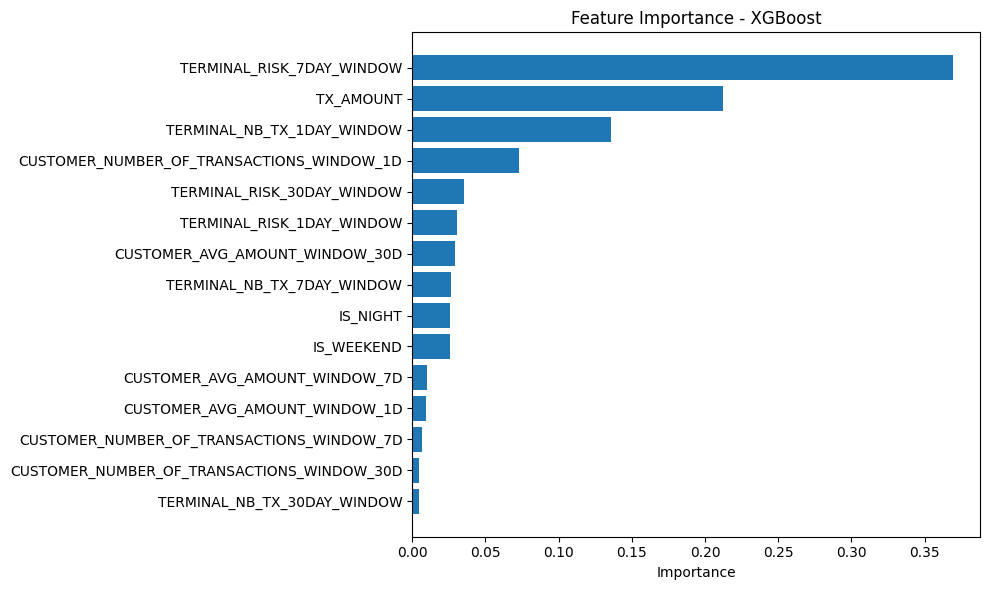

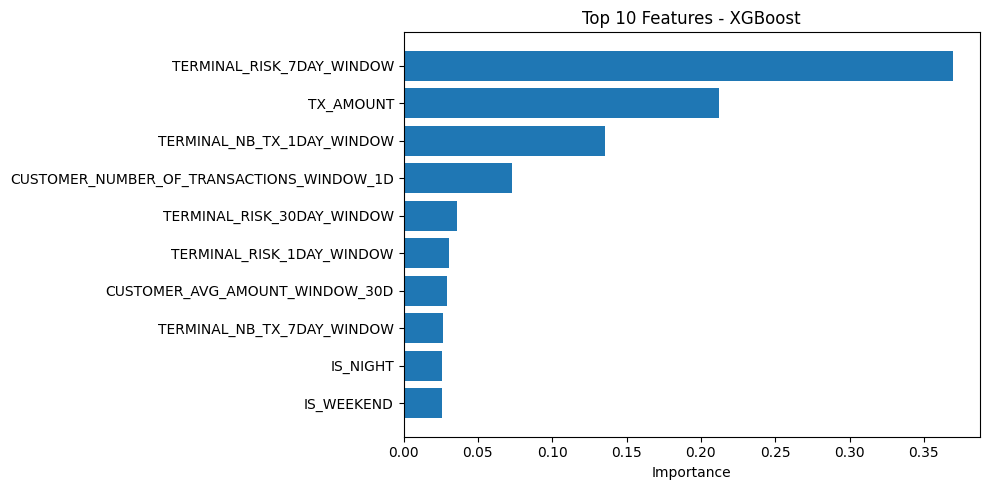

In [15]:
# FEATURE IMPORTANCE ANALYSIS
import matplotlib.pyplot as plt

print(f"\n{'#'*60}")
print("FEATURE IMPORTANCE ANALYSIS")
print(f"{'#'*60}\n")

# Get best model
best_pipeline = best_models[best_model_name]
best_model_obj = best_pipeline.named_steps['model']

# Extract feature importances
feature_importance = pd.DataFrame({
    'feature': feature_cols,
    'importance': best_model_obj.feature_importances_
}).sort_values('importance', ascending=False)

print(f"Top 10 Most Important Features for {best_model_name}:")
print(feature_importance.head(10).to_string(index=False))

# Plot feature importance
plt.figure(figsize=(10, 6))
plt.barh(range(len(feature_importance)), feature_importance['importance'])
plt.yticks(range(len(feature_importance)), feature_importance['feature'])
plt.xlabel('Importance')
plt.title(f'Feature Importance - {best_model_name}')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# Top 10 features
plt.figure(figsize=(10, 5))
top_10 = feature_importance.head(10)
plt.barh(range(len(top_10)), top_10['importance'])
plt.yticks(range(len(top_10)), top_10['feature'])
plt.xlabel('Importance')
plt.title(f'Top 10 Features - {best_model_name}')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [12]:
# SAVE BEST MODEL
import os
from datetime import datetime

import joblib

print(f"\n{'#'*60}")
print("SAVING BEST MODEL")
print(f"{'#'*60}\n")

# Create models directory
os.makedirs('../models', exist_ok=True)

# Timestamp cho filename
timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')

# Save best model pipeline
model_filename = f'../models/fraud_detection_{best_model_name.lower()}_{timestamp}.pkl'
joblib.dump(best_pipeline, model_filename)

print(f"Model saved: {model_filename}")
print("\nTo load model:")
print(f"  model = joblib.load('{model_filename}')")


############################################################
SAVING BEST MODEL
############################################################

Model saved: ../models/fraud_detection_xgboost_20260112_130642.pkl

To load model:
  model = joblib.load('../models/fraud_detection_xgboost_20260112_130642.pkl')
